In [1]:
from google.colab import files
uploaded = files.upload()

Saving Ecommerce Customers.csv to Ecommerce Customers.csv


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

df = pd.read_csv("Ecommerce Customers.csv")
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [10]:
print(df.info())
print(df.describe())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB
None
       Avg. Session Length  Time on App  Time on Website  \
count           500.000000   500.000000       500.000000   
mean             33.053194    12.052488        37.060445   
std               0.992563     0.994216         1.010489   
min              29.532429     8.508152        33.913847   
25%              32.341822  

In [11]:
print(df.isnull().sum())

df = df.drop(columns=["Email", "Address", "Avatar"], errors="ignore")
df = df.drop_duplicates()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64


In [12]:
df["Total Time"] = df["Time on App"] + df["Time on Website"]
df.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent,Total Time
0,34.497268,12.655651,39.577668,4.082621,587.951054,52.233319
1,31.926272,11.109461,37.268959,2.664034,392.204933,48.378420
2,33.000915,11.330278,37.110597,4.104543,487.547505,48.440875
3,34.305557,13.717514,36.721283,3.120179,581.852344,50.438796
4,33.330673,12.795189,37.536653,4.446308,599.406092,50.331842


In [13]:
y = df["Yearly Amount Spent"]
X = df.drop(columns=["Yearly Amount Spent"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=101
)

In [14]:
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

                      Coefficient
Avg. Session Length     25.691540
Time on App             25.074873
Time on Website        -12.257146
Length of Membership    61.648594
Total Time              12.817727


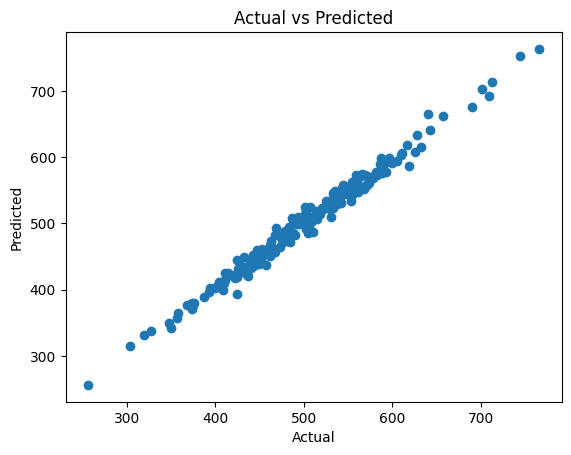

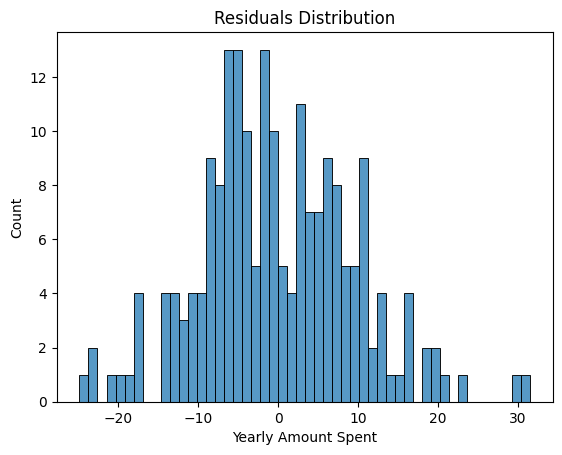

MAE: 7.742671285838705
MSE: 93.83297800820048
RMSE: 9.686742383701576


In [15]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

predictions = lm.predict(X_test)

plt.scatter(y_test, predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

sns.histplot((y_test - predictions), bins=50)
plt.title("Residuals Distribution")
plt.show()

print("MAE:", metrics.mean_absolute_error(y_test, predictions))
print("MSE:", metrics.mean_squared_error(y_test, predictions))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, predictions)))